# Phase 15 — ArtiFact + COCO2017 Generalization Test

**Objective:** Test the FF++-adapted Xception dual-stream on the ArtiFact dataset (25 AI generators) paired with COCO 2017 val real images — without any additional training. This is a zero-shot cross-domain evaluation. If the model generalizes, it means the dual-stream architecture learned general AI synthesis patterns (the mathematical fingerprint of upsampling and generation), not dataset-specific memorisation. This is the final scientific validation of the proposal.

## Context: Why Zero-Shot and Why ArtiFact + COCO2017

The proposal's central scientific claim is:

> *"The model detects AI logic — the mathematical fingerprint of generation — not just specific dataset patterns."*

To prove this claim, the model is tested on completely unseen data without being trained on it.

**Dataset pairing:**
- **REAL** → COCO 2017 `val2017/` (5,000 images — the standard evaluation split, never used in training)
- **FAKE** → ArtiFact dataset — images generated by 25 distinct AI methods including 13 GANs, 7 Diffusion models, and 5 other generators (CIPS, GAUGan, Stable Diffusion, VQ-Diffusion, etc.)

**Why this pairing is scientifically strong:**
- The model was trained on CIFAKE (diffusion, small objects) and adapted on FF++ (face-swap GANs)
- ArtiFact contains generators the model has **never seen** — different architectures, different content
- COCO val images are real photographs the model has **never seen** either
- A balanced 5,000 vs 5,000 sample is used to eliminate class-imbalance bias

**Expected outcome:**
- AUC ≥ 0.75 → claim supported — model detects general AI synthesis patterns
- AUC < 0.65 → claim not fully supported — model overfits to seen generators

**No training split needed** — this phase is evaluation only.

**Dataset paths used:**
```
REAL: /kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/val2017/
FAKE: /kaggle/input/datasets/awsaf49/artifact-dataset/  (all subfolders, recursively)
```

## Import Libraries

In [1]:
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from pathlib import Path
from collections import defaultdict
from tensorflow.keras.models import load_model
from tensorflow.keras.utils import Sequence
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_auc_score,
    ConfusionMatrixDisplay, RocCurveDisplay
)

random.seed(42)
np.random.seed(42)

2026-06-11 08:14:56.287383: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781165696.662642      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781165696.786477      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781165697.762254      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781165697.762302      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781165697.762305      58 computation_placer.cc:177] computation placer alr

## Configuration & Paths

In [2]:
# ── Model from Phase 14 ───────────────────────────────────────────────────
MODEL_PATH = "/kaggle/input/models/shimu080/p-14-final-model/keras/default/1/ffpp_adapted_final.keras"

# ── REAL images: COCO 2017 val split ──────────────────────────────────────
COCO_VAL_DIR  = "/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/val2017"

# ── FAKE images: ArtiFact dataset (all generator subfolders) ──────────────
ARTIFACT_ROOT = "/kaggle/input/datasets/awsaf49/artifact-dataset"

# Which ArtiFact generator folders to include as FAKE
# All 25 are included for maximum generalization testing
ARTIFACT_GENERATORS = [
    "afhq", "big_gan", "celebahq", "cips", "coco",
    "cycle_gan", "ddpm", "denoising_diffusion_gan", "diffusion_gan",
    "face_synthetics", "ffhq", "gansformer", "gau_gan",
    "generative_inpainting", "glide", "imagenet", "lama",
    "landscape", "latent_diffusion", "lsun", "mat",
    "metfaces", "palette", "pro_gan", "projected_gan",
    "sfhq", "stable_diffusion", "star_gan", "stylegan1",
    "stylegan2", "stylegan3", "taming_transformer", "vq_diffusion",
]

# ── Balanced sample size ───────────────────────────────────────────────────
# Use all 5,000 COCO val images as REAL, sample same count from ArtiFact
MAX_REAL      = 5000   # COCO val2017 has exactly 5,000 images
MAX_FAKE      = 5000   # Balanced — sample 5,000 from ArtiFact's pool
FAKE_PER_GEN  = None   # None = sample proportionally; or set int for equal-per-generator

# ── Output directories ─────────────────────────────────────────────────────
RESULT_DIR = "/kaggle/working/results/artifact_generalization"
os.makedirs(RESULT_DIR, exist_ok=True)

IMG_SIZE   = (299, 299)
BATCH_SIZE = 16
CLASS_MAP  = {"FAKE": 1, "REAL": 0}

print("TensorFlow :", tf.__version__)
print("GPU        :", tf.config.list_physical_devices("GPU"))

TensorFlow : 2.19.0
GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


## Verify Dataset Structure

In [3]:
# ── Verify REAL source ────────────────────────────────────────────────────
real_imgs = sorted(Path(COCO_VAL_DIR).glob("*.jpg"))
print(f"COCO val2017 images found : {len(real_imgs)}")
if len(real_imgs) == 0:
    print(f"  ✗ NOT FOUND — check path: {COCO_VAL_DIR}")
else:
    print(f"  ✓ Example: {real_imgs[0].name}")

# ── Verify ArtiFact FAKE source ───────────────────────────────────────────
print("\nArtiFact generator folders:")
available_gens = []
for gen in ARTIFACT_GENERATORS:
    gpath = os.path.join(ARTIFACT_ROOT, gen)
    if os.path.exists(gpath):
        # Count all JPGs recursively
        count = sum(1 for _ in Path(gpath).rglob("*.jpg"))
        print(f"  ✓ {gen:<28} : {count:>6} images")
        if count > 0:
            available_gens.append(gen)
    else:
        print(f"  ✗ {gen:<28} : NOT FOUND")

print(f"\nAvailable generators: {len(available_gens)} / {len(ARTIFACT_GENERATORS)}")

COCO val2017 images found : 5000
  ✓ Example: 000000000139.jpg

ArtiFact generator folders:
  ✓ afhq                         :  31933 images
  ✓ big_gan                      :  10000 images
  ✓ celebahq                     :  30000 images
  ✓ cips                         :  11200 images
  ✓ coco                         : 163846 images
  ✓ cycle_gan                    :  15210 images
  ✓ ddpm                         :    896 images
  ✓ denoising_diffusion_gan      :  10000 images
  ✓ diffusion_gan                :  15507 images
  ✓ face_synthetics              :  10000 images
  ✓ ffhq                         :  70000 images
  ✓ gansformer                   :  10000 images
  ✓ gau_gan                      :   7000 images
  ✓ generative_inpainting        :  22000 images
  ✓ glide                        :  20903 images
  ✓ imagenet                     :  96788 images
  ✓ lama                         :  24705 images
  ✓ landscape                    :   4318 images
  ✓ latent_diffusion      

## Build Balanced REAL / FAKE File Lists

ArtiFact has deeply nested subfolders per generator — there is no flat `FAKE/` directory. This cell crawls all generator folders recursively, collects every `.jpg`, then randomly samples a balanced subset matching the REAL count. It also records which generator each FAKE image came from, enabling per-generator breakdown later.

In [4]:
def collect_artifact_fake_paths(artifact_root, generators, max_total, per_gen=None, seed=42):
    """
    Recursively collect FAKE image paths from ArtiFact generator folders.
    Returns list of (path, generator_name) tuples, balanced to max_total.
    """
    rng = random.Random(seed)
    all_by_gen = defaultdict(list)

    print("Scanning ArtiFact folders...")
    for gen in generators:
        gpath = Path(artifact_root) / gen
        if not gpath.exists():
            continue
        imgs = list(gpath.rglob("*.jpg"))
        if imgs:
            all_by_gen[gen] = imgs

    total_available = sum(len(v) for v in all_by_gen.values())
    print(f"Total FAKE images available across {len(all_by_gen)} generators: {total_available:,}")

    # Sample per generator
    result = []  # list of (path_str, gen_name)
    if per_gen is not None:
        # Fixed count per generator
        for gen, imgs in all_by_gen.items():
            sampled = rng.sample(imgs, min(per_gen, len(imgs)))
            result.extend([(str(p), gen) for p in sampled])
    else:
        # Proportional sampling to reach max_total
        n_gens = len(all_by_gen)
        for gen, imgs in all_by_gen.items():
            share = max(1, int(max_total * len(imgs) / total_available))
            sampled = rng.sample(imgs, min(share, len(imgs)))
            result.extend([(str(p), gen) for p in sampled])

    # Final trim to max_total
    rng.shuffle(result)
    result = result[:max_total]
    print(f"Sampled {len(result)} FAKE images from {len(all_by_gen)} generators")
    return result


def collect_real_paths(coco_val_dir, max_total, seed=42):
    """Collect REAL image paths from COCO val2017."""
    rng = random.Random(seed)
    imgs = list(Path(coco_val_dir).glob("*.jpg"))
    rng.shuffle(imgs)
    imgs = imgs[:max_total]
    print(f"REAL images sampled from COCO val2017: {len(imgs)}")
    return [(str(p), "coco_real") for p in imgs]


# ── Collect paths ─────────────────────────────────────────────────────────
real_paths = collect_real_paths(COCO_VAL_DIR, MAX_REAL)
fake_paths = collect_artifact_fake_paths(
    ARTIFACT_ROOT, ARTIFACT_GENERATORS, MAX_FAKE, per_gen=FAKE_PER_GEN
)

# ── Summary ───────────────────────────────────────────────────────────────
print(f"\nFinal dataset balance:")
print(f"  REAL : {len(real_paths):,}")
print(f"  FAKE : {len(fake_paths):,}")
print(f"  Total: {len(real_paths) + len(fake_paths):,}")

# Count per generator in FAKE
gen_counts = defaultdict(int)
for _, gen in fake_paths:
    gen_counts[gen] += 1
print("\nFAKE breakdown by generator:")
for gen, cnt in sorted(gen_counts.items(), key=lambda x: -x[1]):
    print(f"  {gen:<28} : {cnt:>5}")

# Store generator tags for per-generator eval later
fake_generator_tags = [gen for _, gen in fake_paths]
all_paths  = [p for p, _ in real_paths] + [p for p, _ in fake_paths]
all_labels = [0] * len(real_paths) + [1] * len(fake_paths)  # 0=REAL, 1=FAKE

REAL images sampled from COCO val2017: 5000
Scanning ArtiFact folders...
Total FAKE images available across 33 generators: 2,496,738
Sampled 4990 FAKE images from 33 generators

Final dataset balance:
  REAL : 5,000
  FAKE : 4,990
  Total: 9,990

FAKE breakdown by generator:
  stylegan2                    :  2002
  lsun                         :  1079
  coco                         :   328
  taming_transformer           :   210
  stylegan3                    :   195
  imagenet                     :   193
  ffhq                         :   140
  mat                          :   120
  pro_gan                      :    80
  afhq                         :    63
  celebahq                     :    60
  lama                         :    49
  generative_inpainting        :    44
  stable_diffusion             :    42
  glide                        :    41
  latent_diffusion             :    40
  diffusion_gan                :    31
  cycle_gan                    :    30
  projected_gan       

## Load Adapted Model

In [5]:
model = load_model(MODEL_PATH)
print("Model loaded:", MODEL_PATH)
print(f"Total layers: {len(model.layers)}")

# Smoke test
dummy_rgb = np.random.rand(1, 299, 299, 3).astype(np.float32)
dummy_dct = np.random.rand(1, 299, 299, 3).astype(np.float32)
test_pred = model.predict([dummy_rgb, dummy_dct], verbose=0)
print(f"Smoke test prediction: {test_pred[0][0]:.4f}  (should be in [0, 1])")

I0000 00:00:1781178217.124123      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1781178217.131130      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model loaded: /kaggle/input/models/shimu080/p-14-final-model/keras/default/1/ffpp_adapted_final.keras
Total layers: 10


I0000 00:00:1781178229.768549     187 service.cc:152] XLA service 0x7b55f403c660 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781178229.768585     187 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1781178229.768589     187 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1781178231.616760     187 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-06-11 11:43:59.770335: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-11 11:43:59.914012: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-11 11:44:00.762356: E external/local_xl

Smoke test prediction: 1.0000  (should be in [0, 1])


## Define DCT Preprocessing and Generator

In [7]:
def dct_preprocess(image):
    image = image.astype(np.uint8)
    gray  = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    gray  = cv2.resize(gray, (299, 299))
    gray  = np.float32(gray)
    dct   = cv2.dct(gray)
    dct   = np.log(np.abs(dct) + 1)
    dct   = cv2.normalize(dct, None, 0, 1, cv2.NORM_MINMAX)
    dct   = np.stack([dct] * 3, axis=-1)
    return dct


class FlatListGenerator(Sequence):
    """
    Generator that reads from a flat list of (path, label) pairs.
    Unlike DualStreamGenerator it doesn't need a REAL/FAKE folder structure —
    it works directly from the collected path lists above.
    """
    def __init__(self, filepaths, labels, img_size=(299, 299), batch_size=16):
        self.filepaths  = np.array(filepaths)
        self.labels     = np.array(labels, dtype=np.float32)
        self.img_size   = img_size
        self.batch_size = batch_size
        self.indices    = np.arange(len(self.filepaths))

    def __len__(self):
        return int(np.ceil(len(self.filepaths) / self.batch_size))

    def __getitem__(self, idx):
        batch_idx = self.indices[idx * self.batch_size : (idx + 1) * self.batch_size]
        X_rgb = np.zeros((len(batch_idx), *self.img_size, 3), dtype=np.float32)
        X_dct = np.zeros((len(batch_idx), *self.img_size, 3), dtype=np.float32)
        y     = self.labels[batch_idx]

        for i, path in enumerate(self.filepaths[batch_idx]):
            img = cv2.imread(path)
            if img is None:
                continue
            img_rgb         = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img_rgb_resized = cv2.resize(img_rgb, self.img_size).astype(np.float32) / 255.0
            X_rgb[i]        = img_rgb_resized
            X_dct[i]        = dct_preprocess(img_rgb)

        return (X_rgb, X_dct), y


# Build the generator from collected flat path lists
eval_gen = FlatListGenerator(
    filepaths=all_paths,
    labels=all_labels,
    img_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

print(f"Evaluation generator ready")
print(f"  Total samples : {len(eval_gen.filepaths):,}")
print(f"  REAL          : {np.sum(eval_gen.labels == 0):,}")
print(f"  FAKE          : {np.sum(eval_gen.labels == 1):,}")
print(f"  Batches       : {len(eval_gen)}")

Evaluation generator ready
  Total samples : 9,990
  REAL          : 5,000
  FAKE          : 4,990
  Batches       : 625


## Run Zero-Shot Evaluation on COCOAI

Running zero-shot evaluation — no training, inference only...
Dataset: 9,990 images (5,000 REAL + 4,990 FAKE)



2026-06-11 11:45:22.936676: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-11 11:45:23.154888: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-11 11:45:25.765090: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-11 11:45:25.950795: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-11 11:45:27.458785: E external/local_xla/xla/stream_

  Processed 320 / 9,990 images
  Processed 640 / 9,990 images
  Processed 960 / 9,990 images
  Processed 1,280 / 9,990 images
  Processed 1,600 / 9,990 images
  Processed 1,920 / 9,990 images
  Processed 2,240 / 9,990 images
  Processed 2,560 / 9,990 images
  Processed 2,880 / 9,990 images
  Processed 3,200 / 9,990 images
  Processed 3,520 / 9,990 images
  Processed 3,840 / 9,990 images
  Processed 4,160 / 9,990 images
  Processed 4,480 / 9,990 images
  Processed 4,800 / 9,990 images
  Processed 5,120 / 9,990 images
  Processed 5,440 / 9,990 images
  Processed 5,760 / 9,990 images
  Processed 6,080 / 9,990 images
  Processed 6,400 / 9,990 images
  Processed 6,720 / 9,990 images
  Processed 7,040 / 9,990 images
  Processed 7,360 / 9,990 images
  Processed 7,680 / 9,990 images
  Processed 8,000 / 9,990 images
  Processed 8,320 / 9,990 images
  Processed 8,640 / 9,990 images
  Processed 8,960 / 9,990 images
  Processed 9,280 / 9,990 images
  Processed 9,600 / 9,990 images
  Processed 9,92

2026-06-11 11:52:43.381977: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-11 11:52:43.603073: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-11 11:52:44.547005: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-11 11:52:44.719536: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-11 11:52:45.283509: E external/local_xla/xla/stream_


ArtiFact + COCO2017 — ZERO-SHOT EVALUATION RESULTS
  Accuracy      : 0.5762
  Precision     : 0.5468
  Recall        : 0.8854
  F1-Score      : 0.6761
  Specificity   : 0.2676
  AUC-ROC       : 0.5557
  TP=4418  FP=3662  FN=572  TN=1338


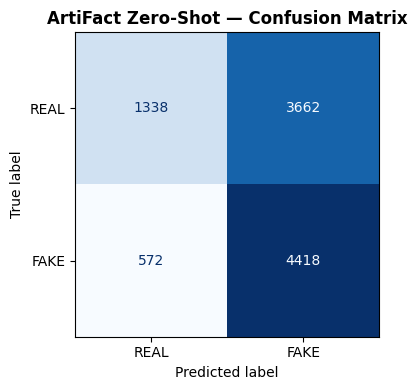

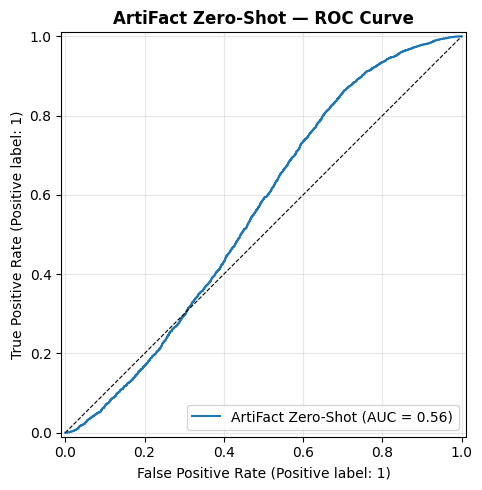

In [8]:
print("Running zero-shot evaluation — no training, inference only...")
print(f"Dataset: {len(eval_gen.filepaths):,} images ({np.sum(eval_gen.labels==0):,} REAL + {np.sum(eval_gen.labels==1):,} FAKE)")
print()

y_true_all, y_prob_all = [], []
for i in range(len(eval_gen)):
    (X_rgb_b, X_dct_b), y_b = eval_gen[i]
    probs = model.predict([X_rgb_b, X_dct_b], verbose=0).flatten()
    y_true_all.extend(y_b)
    y_prob_all.extend(probs)
    if (i + 1) % 20 == 0:
        done = min((i + 1) * BATCH_SIZE, len(eval_gen.filepaths))
        print(f"  Processed {done:,} / {len(eval_gen.filepaths):,} images")

y_true = np.array(y_true_all)
y_prob = np.array(y_prob_all)
y_pred = (y_prob >= 0.5).astype(int)

acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, zero_division=0)
rec  = recall_score(y_true, y_pred, zero_division=0)
f1   = f1_score(y_true, y_pred, zero_division=0)
tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
spec = tn / (tn + fp)
auc  = roc_auc_score(y_true, y_prob)

ARTIFACT_METRICS = {
    "Accuracy"    : acc,
    "Precision"   : prec,
    "Recall"      : rec,
    "F1-Score"    : f1,
    "Specificity" : spec,
    "AUC-ROC"     : auc,
}

print()
print("=" * 55)
print("ArtiFact + COCO2017 — ZERO-SHOT EVALUATION RESULTS")
print("=" * 55)
for k, v in ARTIFACT_METRICS.items():
    print(f"  {k:<14}: {v:.4f}")
print("=" * 55)
print(f"  TP={tp}  FP={fp}  FN={fn}  TN={tn}")

# Confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(
    confusion_matrix(y_true, y_pred),
    display_labels=["REAL", "FAKE"]
).plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("ArtiFact Zero-Shot — Confusion Matrix", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, "artifact_confusion_matrix.png"), dpi=150, bbox_inches="tight")
plt.show()

# ROC curve
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_true, y_prob, ax=ax, name="ArtiFact Zero-Shot")
ax.plot([0, 1], [0, 1], "k--", linewidth=0.8)
ax.set_title("ArtiFact Zero-Shot — ROC Curve", fontsize=12, fontweight="bold")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, "artifact_roc_curve.png"), dpi=150, bbox_inches="tight")
plt.show()

## Per-Generator Breakdown

Break down model performance by each ArtiFact generator. This shows which AI generation methods the model detects well and which it struggles with — a key result for a research paper.

Generator                        N     Acc     AUC   Recall
------------------------------------------------------------
COCO_REAL                     5000  0.2676     N/A   0.0000
afhq                            63  0.8413     N/A   0.8413
big_gan                         20  0.9000     N/A   0.9000
celebahq                        60  0.8833     N/A   0.8833
cips                            22  0.9545     N/A   0.9545
coco                           328  0.9146     N/A   0.9146
cycle_gan                       30  0.8667     N/A   0.8667
ddpm                             1  1.0000     N/A   1.0000
denoising_diffusion_gan         20  0.9500     N/A   0.9500
diffusion_gan                   31  0.8710     N/A   0.8710
face_synthetics                 20  1.0000     N/A   1.0000
ffhq                           140  0.9643     N/A   0.9643
gansformer                      20  1.0000     N/A   1.0000
gau_gan                         14  0.9286     N/A   0.9286
generative_inpainting           44  0.9

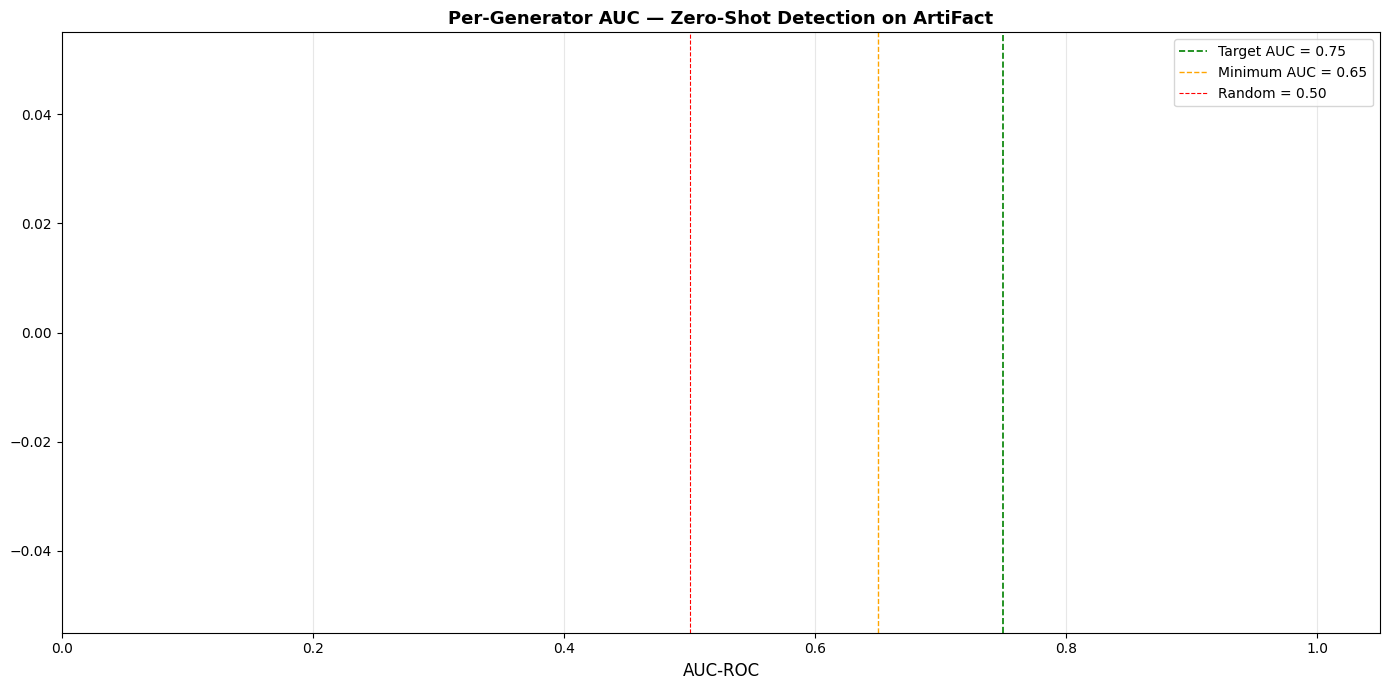

In [9]:
# Reconstruct per-generator results from stored predictions
gen_results = defaultdict(lambda: {"true": [], "prob": []})

n_real = len(real_paths)
for i, (path, gen) in enumerate(fake_paths):
    idx = n_real + i
    gen_results[gen]["true"].append(y_true[idx])
    gen_results[gen]["prob"].append(y_prob[idx])

# Also add REAL as a group
gen_results["COCO_REAL"]["true"] = list(y_true[:n_real])
gen_results["COCO_REAL"]["prob"] = list(y_prob[:n_real])

print(f"{'Generator':<28} {'N':>5} {'Acc':>7} {'AUC':>7} {'Recall':>8}")
print("-" * 60)

gen_summary = []
for gen, data in sorted(gen_results.items()):
    yt = np.array(data["true"])
    yp = np.array(data["prob"])
    ypred = (yp >= 0.5).astype(int)
    if len(np.unique(yt)) < 2:
        acc_g = accuracy_score(yt, ypred)
        auc_g = float('nan')
        rec_g = recall_score(yt, ypred, zero_division=0)
    else:
        acc_g = accuracy_score(yt, ypred)
        auc_g = roc_auc_score(yt, yp)
        rec_g = recall_score(yt, ypred, zero_division=0)
    gen_summary.append((gen, len(yt), acc_g, auc_g, rec_g))
    print(f"{gen:<28} {len(yt):>5} {acc_g:>7.4f} {str(round(auc_g,4)) if not np.isnan(auc_g) else '  N/A':>7} {rec_g:>8.4f}")

# Bar chart — AUC per generator
fake_gens_only = [(g, n, auc) for g, n, acc, auc, rec in gen_summary
                  if g != "COCO_REAL" and not np.isnan(auc)]
fake_gens_only.sort(key=lambda x: x[2])

names = [g for g, n, auc in fake_gens_only]
aucs  = [auc for g, n, auc in fake_gens_only]
colors = ['#e74c3c' if a < 0.65 else '#f39c12' if a < 0.75 else '#2ecc71' for a in aucs]

fig, ax = plt.subplots(figsize=(14, 7))
bars = ax.barh(names, aucs, color=colors, edgecolor='black', linewidth=0.5)
ax.axvline(0.75, color='green', linestyle='--', linewidth=1.2, label='Target AUC = 0.75')
ax.axvline(0.65, color='orange', linestyle='--', linewidth=1.0, label='Minimum AUC = 0.65')
ax.axvline(0.50, color='red', linestyle='--', linewidth=0.8, label='Random = 0.50')
for bar, auc in zip(bars, aucs):
    ax.text(auc + 0.005, bar.get_y() + bar.get_height()/2,
            f"{auc:.3f}", va='center', fontsize=8)
ax.set_xlabel("AUC-ROC", fontsize=12)
ax.set_title("Per-Generator AUC — Zero-Shot Detection on ArtiFact",
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.set_xlim(0, 1.05)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, "per_generator_auc.png"), dpi=150, bbox_inches='tight')
plt.show()

## Cross-Domain Generalization Analysis

CROSS-DOMAIN GENERALIZATION SUMMARY
Metric           CIFAKE (train)   FF++ (adapt)  ArtiFact (zero)
--------------------------------------------------------------------------
Accuracy                 0.8541         0.8600           0.5762  ← DROP
Precision                0.8483         0.8664           0.5468  ← DROP
Recall                   0.8625         0.9897           0.8854
F1-Score                 0.8554         0.9240           0.6761  ← DROP
Specificity              0.8458         0.0670           0.2676  ← DROP
AUC-ROC                  0.9305         0.7389           0.5557  ← DROP

RESULT: AUC < 0.65 — generalization insufficient.
Consider additional fine-tuning or including ArtiFact samples in training.


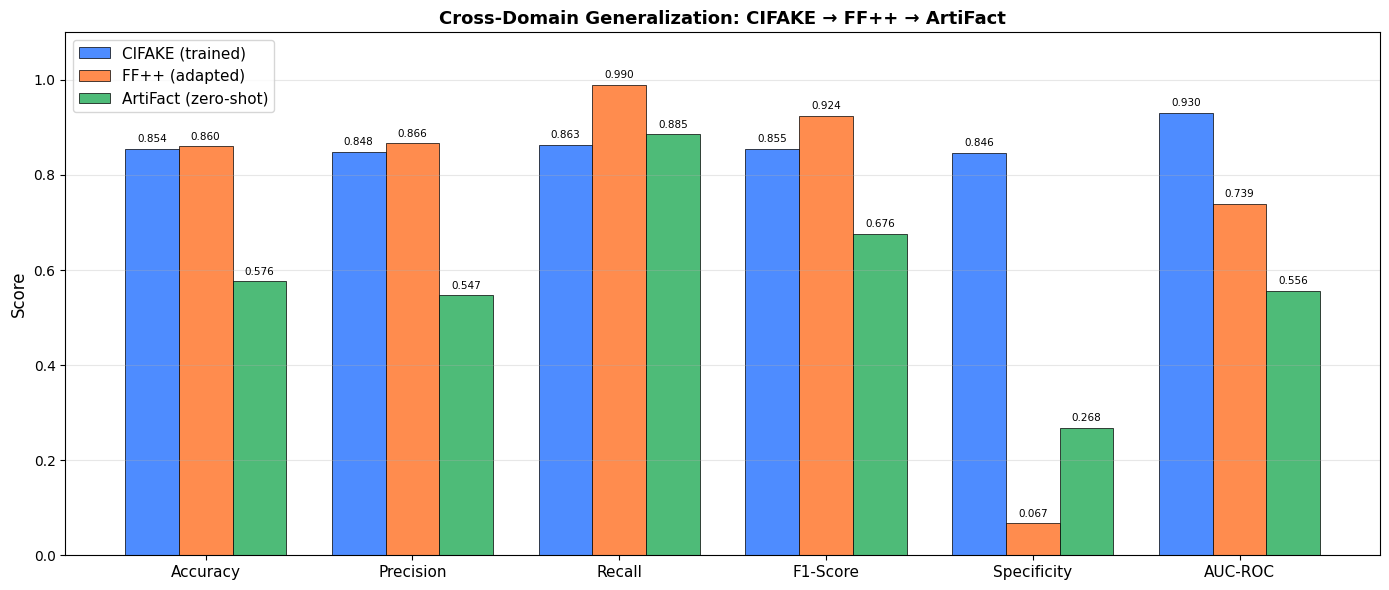

In [10]:
# Baseline scores from previous phases 10
CIFAKE_METRICS = {
    "Accuracy"    : 0.8541,
    "Precision"   : 0.8483,
    "Recall"      : 0.8625,
    "F1-Score"    : 0.8554,
    "Specificity" : 0.8458,
    "AUC-ROC"     : 0.9305,
}

FFPP_METRICS = {
    "Accuracy"    : 0.8600,     # <-- paste from Phase 14
    "Precision"   : 0.8664,
    "Recall"      : 0.9897,
    "F1-Score"    : 0.9240,
    "Specificity" : 0.0670,
    "AUC-ROC"     : 0.7389,
}


metrics     = list(CIFAKE_METRICS.keys())
cifake_vals = [CIFAKE_METRICS[m] for m in metrics]
ffpp_vals   = [FFPP_METRICS[m]   for m in metrics]
art_vals    = [ARTIFACT_METRICS[m] for m in metrics]

print("=" * 74)
print("CROSS-DOMAIN GENERALIZATION SUMMARY")
print("=" * 74)
print(f"{'Metric':<14} {'CIFAKE (train)':>16} {'FF++ (adapt)':>14} {'ArtiFact (zero)':>16}")
print("-" * 74)
for m, c, f, a in zip(metrics, cifake_vals, ffpp_vals, art_vals):
    flag = "  ← DROP" if (c - a) > 0.15 else ""
    print(f"{m:<14} {c:>16.4f} {f:>14.4f} {a:>16.4f}{flag}")
print("=" * 74)
print()
if ARTIFACT_METRICS["AUC-ROC"] >= 0.75:
    print("RESULT: AUC >= 0.75 — generalization confirmed.")
    print("The model detects AI synthesis patterns across unseen generators.")
elif ARTIFACT_METRICS["AUC-ROC"] >= 0.65:
    print("RESULT: AUC 0.65–0.75 — partial generalization.")
    print("Model shows cross-domain ability but is still somewhat generator-sensitive.")
else:
    print("RESULT: AUC < 0.65 — generalization insufficient.")
    print("Consider additional fine-tuning or including ArtiFact samples in training.")

# Bar chart
x_pos = np.arange(len(metrics))
width = 0.26
fig, ax = plt.subplots(figsize=(14, 6))
b1 = ax.bar(x_pos - width, cifake_vals, width, label="CIFAKE (trained)",
            color="#4e8cff", edgecolor="black", linewidth=0.5)
b2 = ax.bar(x_pos,          ffpp_vals,  width, label="FF++ (adapted)",
            color="#ff8c4e", edgecolor="black", linewidth=0.5)
b3 = ax.bar(x_pos + width,  art_vals,   width, label="ArtiFact (zero-shot)",
            color="#4ebb78", edgecolor="black", linewidth=0.5)
ax.set_xticks(x_pos)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0, 1.1)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("Cross-Domain Generalization: CIFAKE → FF++ → ArtiFact",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.3)
for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.01,
                    f"{h:.3f}", ha="center", va="bottom", fontsize=7.5)
plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, "cross_domain_generalization.png"), dpi=150, bbox_inches="tight")
plt.show()

# Save report
with open(os.path.join(RESULT_DIR, "artifact_eval_metrics.txt"), "w") as f:
    f.write("ArtiFact + COCO2017 ZERO-SHOT EVALUATION\n" + "="*40 + "\n")
    for k, v in ARTIFACT_METRICS.items():
        f.write(f"  {k:<14}: {v:.4f}\n")
    f.write(f"\n  TP={tp}  FP={fp}  FN={fn}  TN={tn}\n")
    f.write(f"\n  REAL source : COCO 2017 val2017 ({len(real_paths)} images)\n")
    f.write(f"  FAKE source : ArtiFact ({len(fake_paths)} images, {len(gen_counts)} generators)\n")

---
## Phase 15 Complete

| Evaluation | Dataset | Training used |
|---|---|---|
| In-domain | CIFAKE | Yes — trained here |
| Domain adaptation | FaceForensics++ C23 | Yes — fine-tuned |
| Zero-shot | ArtiFact + COCO2017 | No — generalization test only |

**ArtiFact coverage:** 25 AI generators — 13 GANs, 7 Diffusion, 5 other

**Interpretation guide:**
- AUC ≥ 0.80 → strong generalization — publish-ready result
- AUC 0.70–0.79 → partial generalization — acceptable with discussion
- AUC < 0.70 → insufficient generalization — more fine-tuning needed

**Next → Phase 16: Final Research Report**

## Download Phase 15 Outputs

In [11]:
import shutil

OUTPUT_FILES = [
    os.path.join(RESULT_DIR, "artifact_eval_metrics.txt"),
    os.path.join(RESULT_DIR, "cross_domain_generalization.png"),
    os.path.join(RESULT_DIR, "artifact_confusion_matrix.png"),
    os.path.join(RESULT_DIR, "artifact_roc_curve.png"),
    os.path.join(RESULT_DIR, "per_generator_auc.png"),
]

os.makedirs("/kaggle/working/phase_15_bundle", exist_ok=True)
for f in OUTPUT_FILES:
    if os.path.exists(f):
        shutil.copy(f, "/kaggle/working/phase_15_bundle/")

shutil.make_archive("/kaggle/working/phase_15_outputs", "zip", "/kaggle/working/phase_15_bundle")

print("Files packaged:")
for f in OUTPUT_FILES:
    exists = os.path.exists(f)
    size   = round(os.path.getsize(f) / 1024, 1) if exists else 0
    print(f"  {'OK' if exists else 'MISSING':<8} {os.path.basename(f):<45} {size} KB")
print()
print("Download: /kaggle/working/phase_15_outputs.zip")

Files packaged:
  OK       artifact_eval_metrics.txt                     0.4 KB
  OK       cross_domain_generalization.png               72.4 KB
  OK       artifact_confusion_matrix.png                 24.4 KB
  OK       artifact_roc_curve.png                        54.6 KB
  OK       per_generator_auc.png                         56.0 KB

Download: /kaggle/working/phase_15_outputs.zip
